In [1]:
import os
os.chdir('../../..')
print(os.getcwd())

/Users/titonka/FAIRIS


In [2]:
from Simulation.libraries.SimulationLib.Environment import *
import random
import pickle
import matplotlib.pyplot as plt

In [3]:
random_x = [round(random.uniform(-2.5,2.5),2) for i in range(100)]
random_y = [round(random.uniform(-2.5,2.5),2) for i in range(100)]
print(random_x)
print(random_y)
test_points = tuple(zip(random_x,random_y))

[2.4, 1.31, -0.9, 1.71, -0.03, -1.22, -2.34, 0.39, -1.81, -1.96, 0.35, 1.22, 2.29, 2.09, 1.21, 1.2, 1.74, 2.48, 0.73, 0.19, 0.71, -1.8, -1.0, 1.0, 0.91, 1.82, -1.29, -0.2, -2.23, -0.89, -0.1, 1.81, -0.61, 1.66, -1.19, -0.59, -1.3, 0.54, 0.16, 1.5, 2.26, -2.32, 2.26, -0.55, -1.21, 2.47, -0.76, 2.45, -1.15, -0.61, -1.41, -1.05, -2.44, -2.36, 1.84, 0.63, -1.17, 0.25, 1.95, -1.52, -0.68, -1.39, -1.58, 0.96, 1.01, 1.55, -2.33, -2.1, 0.56, -1.76, 0.88, 0.63, 1.4, 2.4, -2.34, -1.4, 1.53, 1.6, 1.42, 0.23, 1.01, 1.91, 0.52, 2.26, -1.98, -2.39, -1.91, -1.92, 1.96, -0.05, 0.06, 0.15, -2.16, 0.92, -1.28, 0.25, 1.44, -1.13, -1.43, 1.52]
[1.57, 2.46, -0.95, 1.14, 1.43, -1.82, -0.61, 1.94, -2.16, 2.27, 1.8, 1.81, 2.35, -2.1, -1.07, -1.81, -1.51, -0.48, -2.49, -2.22, 0.38, -0.91, 1.33, -2.31, -2.11, 2.26, -0.51, -0.52, 1.6, 1.95, 1.84, -1.53, -1.72, -1.99, 0.11, 1.37, 0.6, -2.22, 2.41, -0.12, -0.58, -0.43, 0.98, -1.11, 2.07, -0.49, 1.85, -0.41, -0.37, -2.19, -1.56, 0.52, -2.44, -0.73, -1.0, 0.31, 1.64

In [4]:
uniform_pc = ['6','9','12']
pc_networks =[]
for pc_version in uniform_pc:
    pc_network_name = 'uniform'+'_'+pc_version
    with open("Simulation/GeneratedPCNetworks/" + pc_network_name, 'rb') as pc_file:
        pc_networks.append(pickle.load(pc_file))

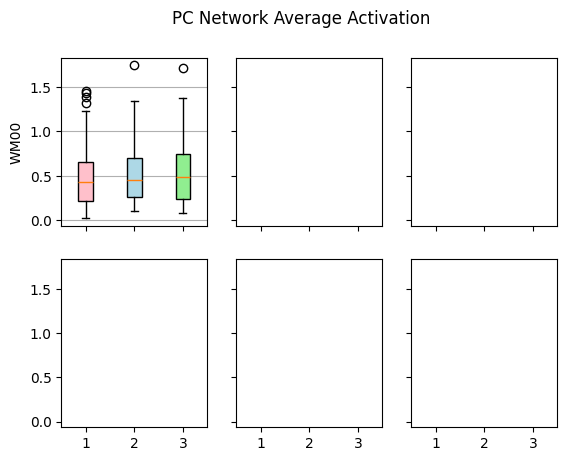

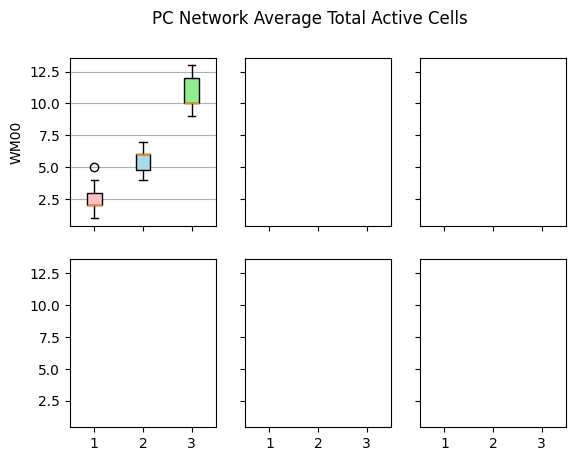

In [5]:
pc_versions = ['6', '9', '12']
fig_op, ax_op = plt.subplots(nrows=1, ncols=2, sharey=True,sharex=True)
fig_op.suptitle("PC Network Average Activation")
fig_co, ax_co = plt.subplots(nrows=2, ncols=3, sharey=True,sharex=True)
fig_op.suptitle("PC Network Average Activation")
fig_co.suptitle("PC Network Average Total Active Cells")
row_counter = 0
col_counter = 0
activation_data =[]
num_cell_data = []
for pc in pc_versions:
    pc_network_name = 'uniform'+'_'+pc
    activations = []
    num_cells = []
    with open("Simulation/GeneratedPCNetworks/" + pc_network_name, 'rb') as pc_file:
        pc_network = pickle.load(pc_file)
    for p in test_points:
        pc_network.activate_pc_network(p[0],p[1])
        activations.append(pc_network.get_total_pc_activation())
        num_cells.append(pc_network.get_num_active_pc(p[0],p[1],search_radius=1))    
    activation_data.append(activations)
    num_cell_data.append(num_cells)
bp = ax_op[row_counter,col_counter].boxplot(activation_data, patch_artist=True)
bp1 = ax_co[row_counter,col_counter].boxplot(num_cell_data, patch_artist=True)

colors = ['pink','lightblue','lightgreen','orange','purple']
for patch, color in zip(bp['boxes'],colors):
    patch.set_facecolor(color)
for patch, color in zip(bp1['boxes'],colors):
    patch.set_facecolor(color)
    
ax_op[row_counter,col_counter].yaxis.grid(True)
ax_co[row_counter,col_counter].yaxis.grid(True)

if col_counter == 0:
    x_lab = 'PC Uniform 6x6'
elif col_counter == 1:
    x_lab = 'PC Uniform 9x9'
else:
    x_lab = 'PC Uniform 12x12'
    
if row_counter == 1:
    ax_op[row_counter,col_counter].set_xlabel(x_lab)
    ax_co[row_counter,col_counter].set_xlabel(x_lab)
if row_counter == 1 and col_counter ==0:
    ax_op[row_counter,col_counter].set_ylabel('WM10')
    ax_co[row_counter,col_counter].set_ylabel('WM10')
elif row_counter == 0 and col_counter ==0:
    ax_op[row_counter,col_counter].set_ylabel('WM00')
    ax_co[row_counter,col_counter].set_ylabel('WM00')
col_counter +=1
row_counter += 1
col_counter = 0

Text(0.5, 0.98, 'Place Cell Networks Metrics')

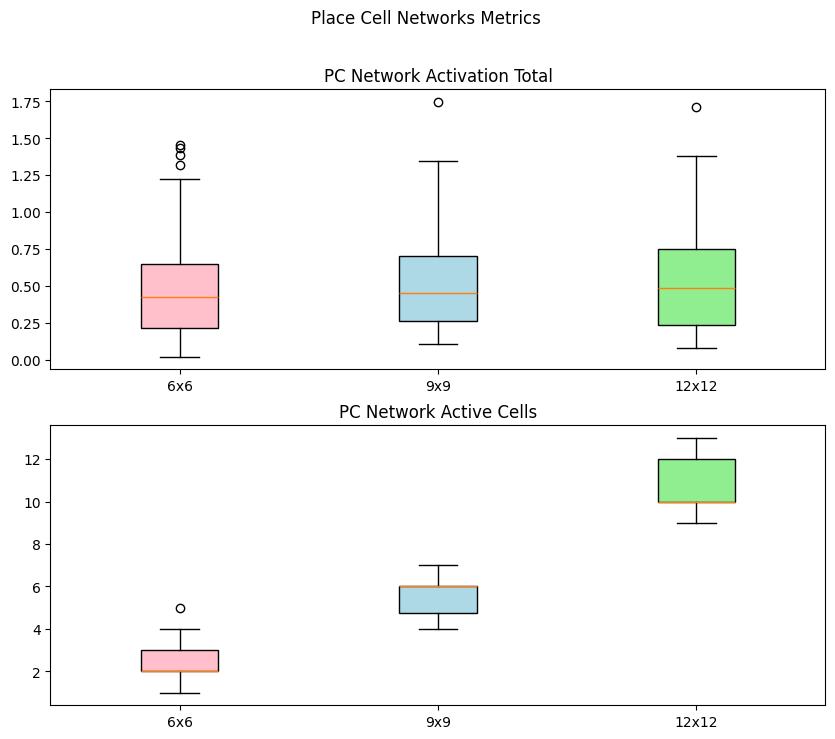

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (10,8))
pc_versions = ['6', '9', '12']
activation_data =[]
num_cell_data = []
for pc in pc_versions:
    pc_network_name = 'uniform'+'_'+pc
    activations = []
    num_cells = []
    with open("Simulation/GeneratedPCNetworks/" + pc_network_name, 'rb') as pc_file:
        pc_network = pickle.load(pc_file)
    for p in test_points:
        pc_network.activate_pc_network(p[0],p[1])
        activations.append(pc_network.get_total_pc_activation())
        num_cells.append(pc_network.get_num_active_pc(p[0],p[1],search_radius=1))    
    activation_data.append(activations)
    num_cell_data.append(num_cells)
    
bp = ax1.boxplot(activation_data, patch_artist=True)
bp1 = ax2.boxplot(num_cell_data, patch_artist=True)

colors = ['pink','lightblue','lightgreen','orange','purple']
for patch, color in zip(bp['boxes'],colors):
    patch.set_facecolor(color)
for patch, color in zip(bp1['boxes'],colors):
    patch.set_facecolor(color)
    
ax1.set_xticklabels(['6x6', '9x9','12x12'])
ax2.set_xticklabels(['6x6', '9x9','12x12'])

ax1.set_title('PC Network Activation Total')
ax2.set_title('PC Network Active Cells')
plt.suptitle('Place Cell Networks Metrics')

In [7]:
maze_files = ['WM00','WM10']
pc_versions = ['0_0', '0_1', '0_2', '0_3', '0_4',
               '1_0', '1_1', '1_2', '1_3', '1_4',
               '2_0', '2_1', '2_2', '2_3', '2_4']
pc_networks =[]
for maze_file in maze_files:
    for pc_version in pc_versions:
        pc_network_name = maze_file+'_'+pc_version
        with open("Simulation/GeneratedPCNetworks/" + pc_network_name, 'rb') as pc_file:
            pc_networks.append(pickle.load(pc_file))

In [8]:

print(test_points)

((0.13, -1.55), (-0.47, -2.07), (0.38, 0.03), (1.35, -2.47), (-0.05, 0.32), (0.05, 0.04), (0.15, -0.23), (-1.52, 1.53), (2.03, -0.1), (-1.7, 0.7), (2.33, 1.19), (0.52, 1.77), (-1.2, -1.82), (-1.69, 0.33), (0.33, -1.48), (1.14, 1.63), (-1.98, 1.55), (-1.32, 1.53), (2.39, -0.01), (0.73, -0.33), (-1.15, 1.99), (-0.47, 0.49), (-2.47, 1.16), (-1.4, -2.16), (2.07, 1.16), (-1.59, -0.84), (-1.69, -2.0), (0.65, 2.17), (1.95, 1.21), (1.01, -0.56), (0.59, -2.0), (-1.92, 2.49), (2.33, -1.79), (-2.41, -0.07), (2.07, 1.63), (0.95, 2.38), (1.62, -1.44), (0.4, -2.34), (-1.49, -2.23), (0.22, 0.84), (-1.45, -1.69), (0.75, 1.61), (-2.09, -1.89), (0.71, 0.61), (2.19, -0.88), (0.05, 2.02), (-1.83, 0.19), (-1.65, 1.66), (-0.35, -2.04), (1.15, -1.75), (1.55, -2.28), (-1.39, -0.27), (-0.99, -1.16), (-1.4, -2.23), (0.51, 1.75), (2.22, 0.49), (0.56, -0.52), (-0.08, -1.79), (1.65, -0.42), (1.25, -2.44), (0.54, -0.43), (-0.3, 1.94), (2.49, -1.08), (-1.96, 0.94), (0.32, -1.84), (1.14, -0.05), (-0.69, 0.62), (0.56,

In [13]:
test_pc = pc_networks[0]
test_point = test_points[0]
test_pc.activate_pc_network(test_point[0],test_point[1])
activation = test_pc.get_total_pc_activation()
num_cells = test_pc.get_num_active_pc(test_point[0],test_point[1],search_radius=.5)
print(activation,num_cells)

0.6906583662999821 1


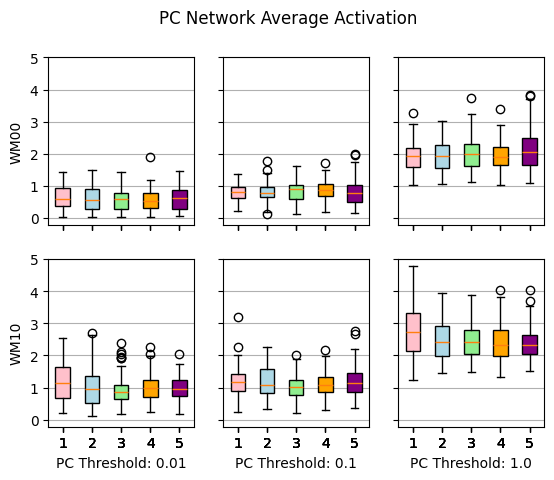

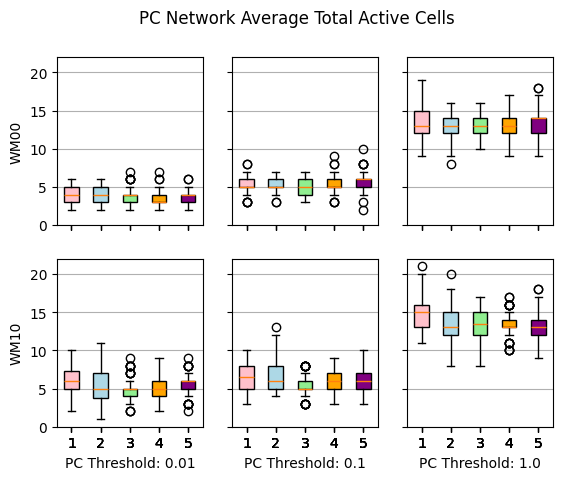

In [31]:
maze_files = ['WM00','WM10']
pc_versions = [['0_0', '0_1', '0_2', '0_3', '0_4'],
               ['1_0', '1_1', '1_2', '1_3', '1_4'],
               ['2_0', '2_1', '2_2', '2_3', '2_4']]
fig_op, ax_op = plt.subplots(nrows=2, ncols=3, sharey=True,sharex=True)
fig_op.suptitle("PC Network Average Activation")
fig_co, ax_co = plt.subplots(nrows=2, ncols=3, sharey=True,sharex=True)
fig_op.suptitle("PC Network Average Activation")
fig_co.suptitle("PC Network Average Total Active Cells")
row_counter = 0
col_counter = 0
for maze_file in maze_files:
    for pc_version in pc_versions:
        activation_data = []
        num_cell_data =[]
        for pc in pc_version:
            pc_network_name = maze_file+'_'+pc
            activations = []
            num_cells = []
            with open("Simulation/GeneratedPCNetworks/" + pc_network_name, 'rb') as pc_file:
                pc_network = pickle.load(pc_file)
            for p in test_points:
                pc_network.activate_pc_network(p[0],p[1])
                activations.append(pc_network.get_total_pc_activation())
                num_cells.append(pc_network.get_num_active_pc(p[0],p[1],search_radius=1))    
            activation_data.append(activations)
            num_cell_data.append(num_cells)
        bp = ax_op[row_counter,col_counter].boxplot(activation_data, patch_artist=True)
        bp1 = ax_co[row_counter,col_counter].boxplot(num_cell_data, patch_artist=True)
        
        colors = ['pink','lightblue','lightgreen','orange','purple']
        for patch, color in zip(bp['boxes'],colors):
            patch.set_facecolor(color)
        for patch, color in zip(bp1['boxes'],colors):
            patch.set_facecolor(color)
            
        ax_op[row_counter,col_counter].yaxis.grid(True)
        ax_co[row_counter,col_counter].yaxis.grid(True)
        
        if col_counter == 0:
            x_lab = 'PC Threshold: 0.01'
        elif col_counter == 1:
            x_lab = 'PC Threshold: 0.1'
        else:
            x_lab = 'PC Threshold: 1.0'
            
        if row_counter == 1:
            ax_op[row_counter,col_counter].set_xlabel(x_lab)
            ax_co[row_counter,col_counter].set_xlabel(x_lab)
        if row_counter == 1 and col_counter ==0:
            ax_op[row_counter,col_counter].set_ylabel('WM10')
            ax_co[row_counter,col_counter].set_ylabel('WM10')
        elif row_counter == 0 and col_counter ==0:
            ax_op[row_counter,col_counter].set_ylabel('WM00')
            ax_co[row_counter,col_counter].set_ylabel('WM00')
        col_counter +=1
    row_counter += 1
    col_counter = 0